# Interval Analysis
# Determing Uniform Mult-Year Interval
# Jonathan H. Morgan, Ph.D. & Sarah Delmar, Ph.D.

In [1]:
#   Packages
    library(data.table)

In [2]:
#   Setting Work Directory
    setwd("/workspace/caffeine_citation/data")

#   Loading Data
    load("/workspace/caffeine_citation/data/caffeine_articles_20April2021.Rda")

## Step 1: Flatten Article–Reference Year Pairs
Parse each article's publication year (`PY`) and the publication year embedded in each cited reference (`CR`). The CR field format is `"Author, YEAR, JOURNAL, VOL, PAGE, DOI"`. Build a data.table of `(article_year, ref_year)` pairs for lag analysis.

In [ ]:
#	Parse Reference Year from a CR String
	parse_ref_year <- function(ref) {
		#	"""
		#	Args:
		#		ref: list of character vectors (one CR entry)
		#	Returns:
		#		integer year or NA_integer_
		#	"""
		ref_str <- sub("^CR ", "", paste(unlist(ref), collapse = " "))
		parts <- trimws(strsplit(ref_str, ",")[[1]])
		if (length(parts) < 2) return(NA_integer_)
		yr <- suppressWarnings(as.integer(parts[2]))
		if (is.na(yr) || yr < 1800 || yr > 2025) return(NA_integer_)
		yr
	}

#	Flatten All Articles into Year Pairs
	pair_list <- vector("list", length = length(file_outputs))

	for (ci in seq_along(file_outputs)) {
		chunk <- file_outputs[[ci]]
		rows <- vector("list", length = length(chunk))
		for (ai in seq_along(chunk)) {
			art <- chunk[[ai]]
			py_raw <- art$PY
			if (is.null(py_raw)) next
			py <- suppressWarnings(as.integer(py_raw[[1]][2]))
			if (is.na(py) || is.null(art$CR)) next

			#	Parse all reference years for this article
				ryrs <- vapply(art$CR, parse_ref_year, integer(1))
				good <- !is.na(ryrs)
				if (any(good)) {
					rows[[ai]] <- data.table(
						article_year = py,
						ref_year = ryrs[good]
					)
				}
		}
		pair_list[[ci]] <- rbindlist(rows)
	}

#	Construct Summary Table
	cite_pairs <- rbindlist(pair_list)
	cite_pairs[, lag := article_year - ref_year]

	cat("Article-reference pairs:", nrow(cite_pairs), "\n")
	summary(cite_pairs)

## Step 2: Citation Capture by Window Width
For candidate window widths (1–20 years), compute the share of article–reference pairs whose lag falls within the window. This is the measurement that decides the interval: the width at which the marginal gain flattens.

In [4]:
#	Citation Capture Rate by Window Width
	widths <- 1:20
	n_valid <- cite_pairs[lag >= 0, .N]

	capture <- data.table(
		window = widths,
		share = vapply(widths, function(w) {
			cite_pairs[lag >= 0 & lag <= w, .N] / n_valid
		}, numeric(1))
	)
	capture[, marginal := c(share[1], diff(share))]

	capture

window,share,marginal
<int>,<dbl>,<dbl>
1,0.07923974,0.07923974
2,0.16478787,0.08554813
3,0.24865307,0.08386521
4,0.32735653,0.07870346
5,0.39892774,0.07157121
6,0.46388243,0.06495469
7,0.52194477,0.05806233
8,0.57416602,0.05222125
9,0.62093061,0.04676459


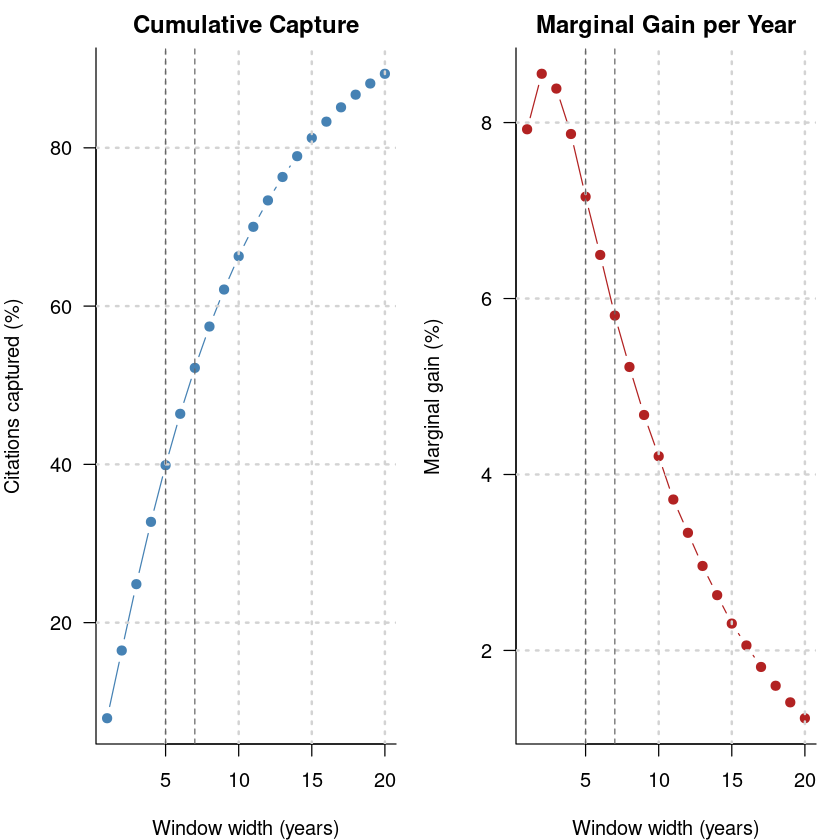

In [7]:
#	Plot: Cumulative Capture and Marginal Gain
	par(mfrow = c(1, 2), mar = c(4, 4, 2, 1))

	#	Cumulative capture
		plot(capture$window, capture$share * 100,
			type = "b", pch = 19, col = "steelblue",
			xlab = "Window width (years)", ylab = "Citations captured (%)",
			main = "Cumulative Capture", bty="L", las=1)
		grid(lwd = 2)
		abline(v = 5, lty = 2, col = "grey40")
		abline(v = 7, lty = 2, col = "grey40")

	#	Marginal gain per additional year
		plot(capture$window, capture$marginal * 100,
			type = "b", pch = 19, col = "firebrick",
			xlab = "Window width (years)", ylab = "Marginal gain (%)",
			main = "Marginal Gain per Year", bty="L", las=1)
		grid(lwd = 2)
		abline(v = 5, lty = 2, col = "grey40")
		abline(v = 7, lty = 2, col = "grey40")